# Machine centering and inspection yield

**A simulated machining-quality case study.** The decision is whether correcting a diameter offset is sufficient to address the modeled inspection losses. No factory observations, physical Gage R&R or realized savings are claimed.

The generator deliberately assigns machine offsets, thermal response and categorical failure probabilities. The contribution is checking inspection consistency, separating dimensional from total-yield effects, and testing how the modeled decision changes under imperfect centering. This is not independent discovery of a physical root cause.

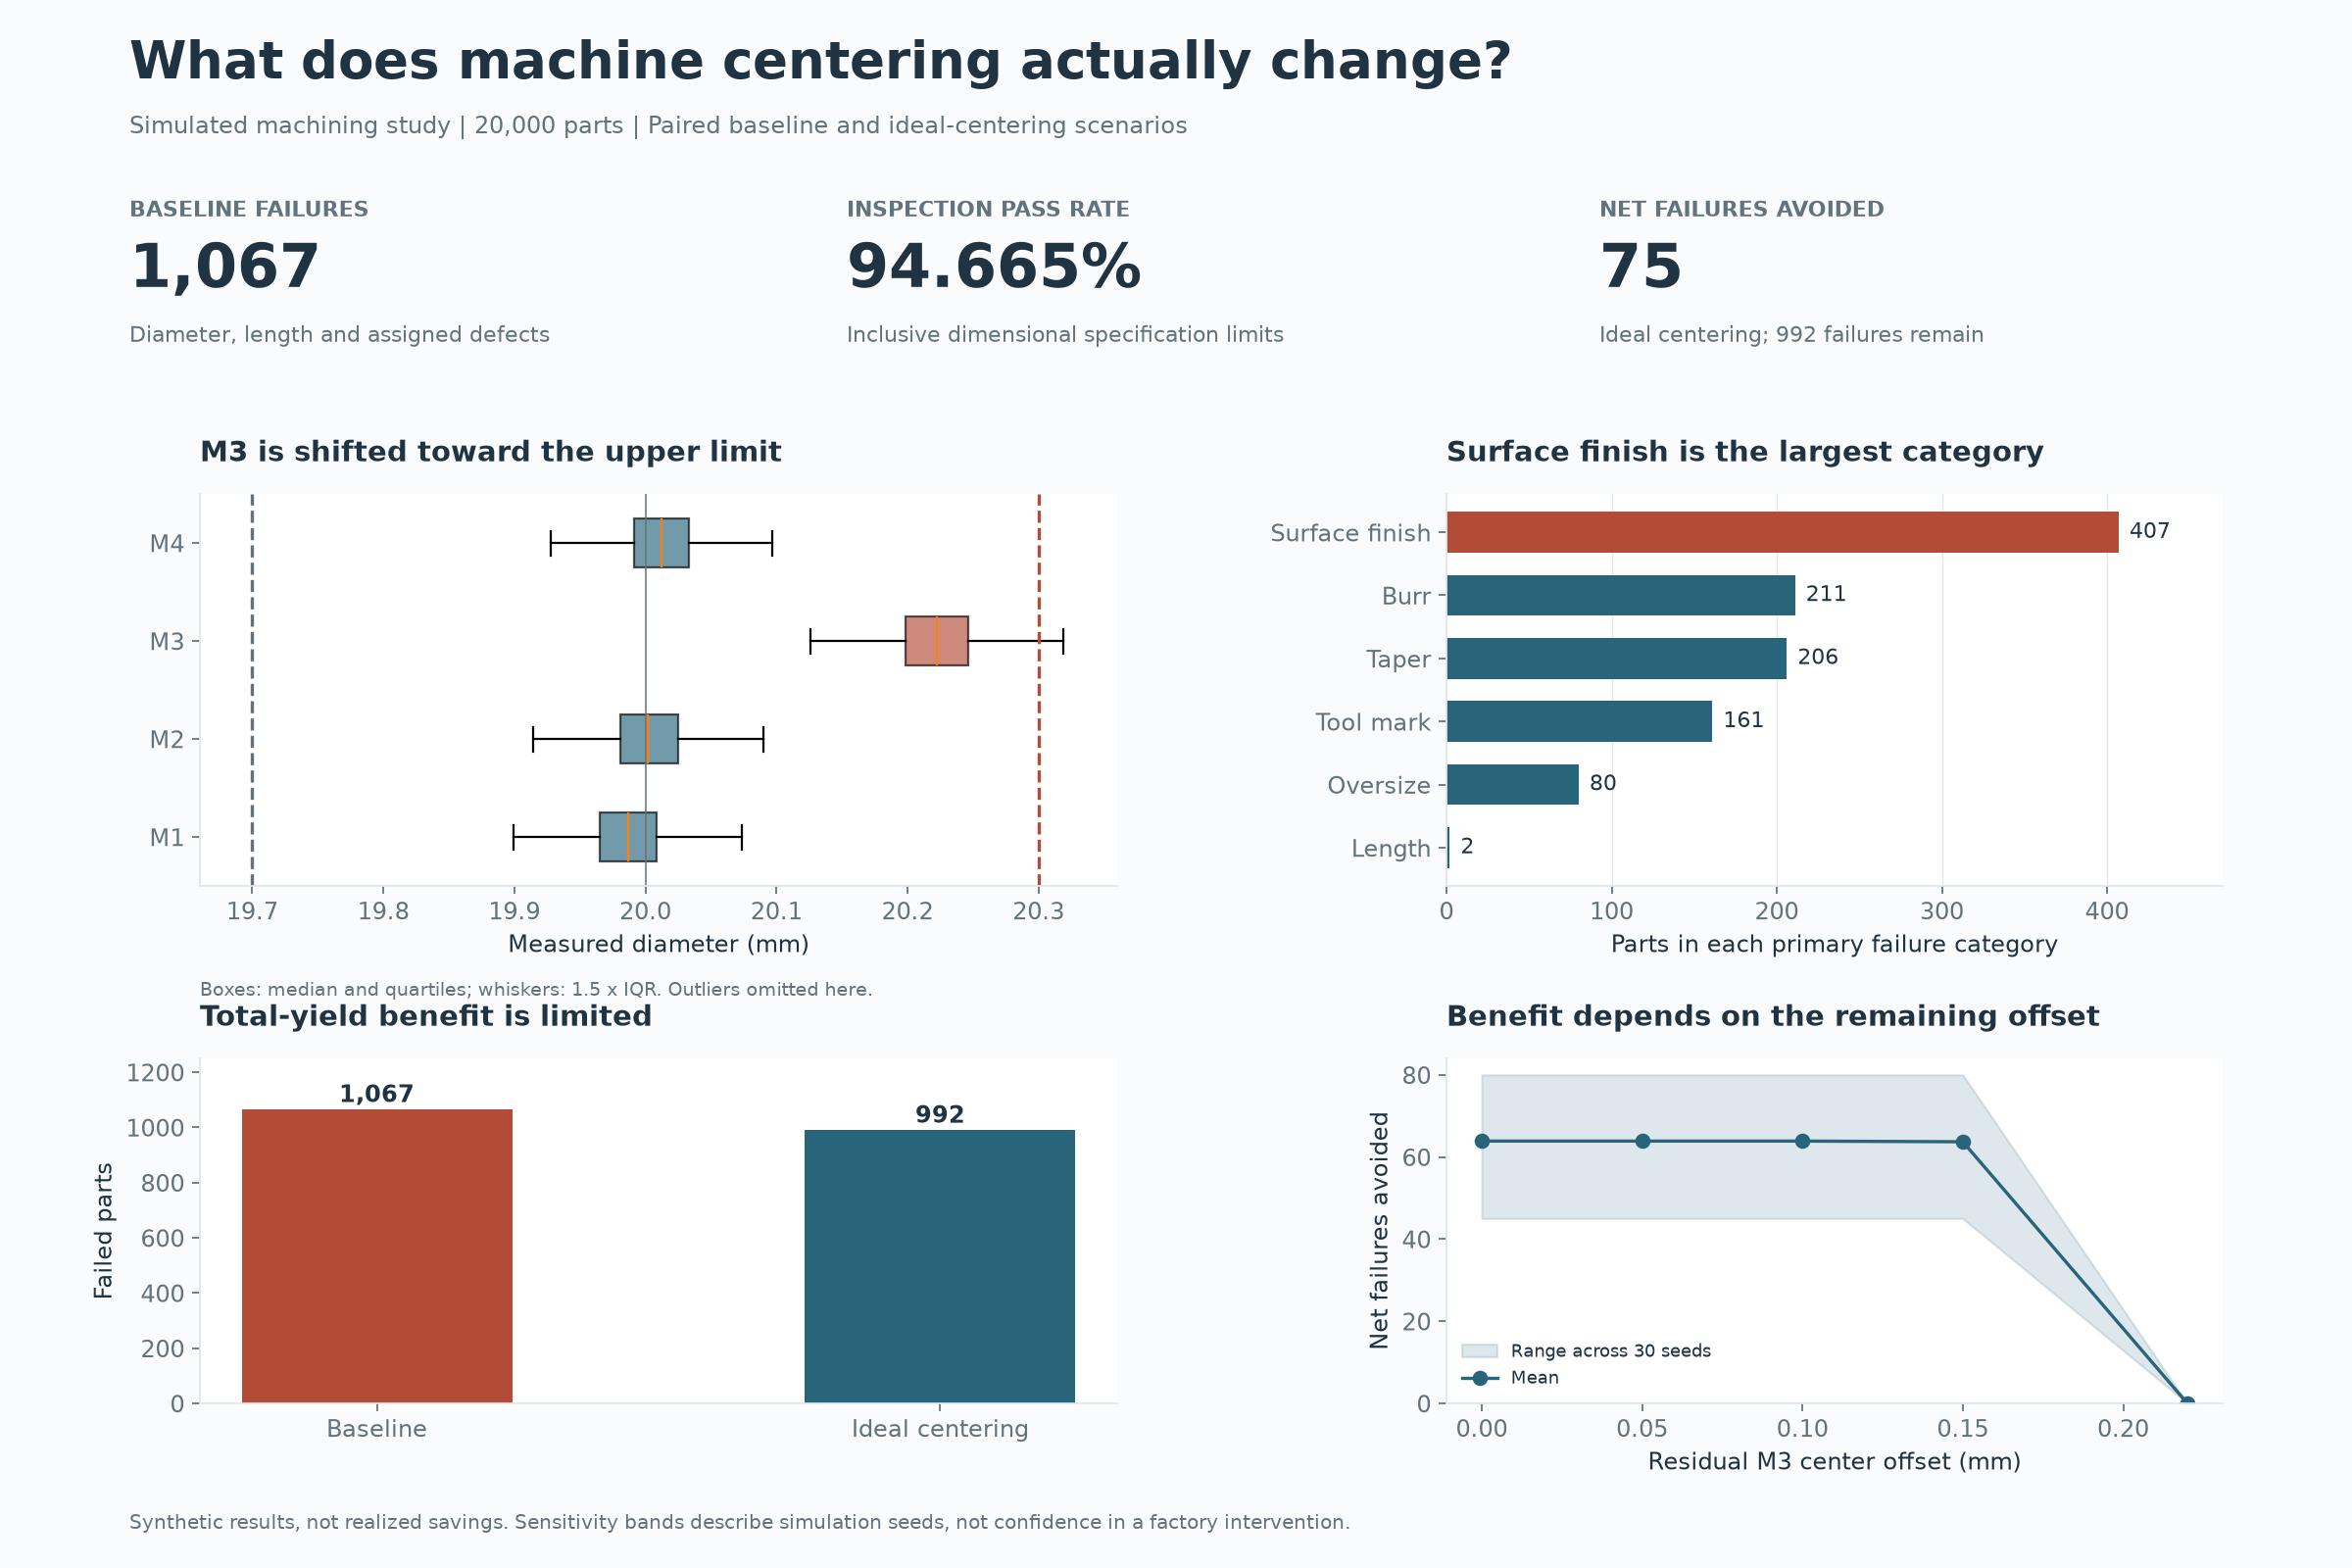

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from analysis import summary, validate, gage_analysis, machine_summary
from generate_data import generate_production_data
ROOT=Path.cwd()
d=pd.read_csv(ROOT/'data/manufacturing.csv',keep_default_na=False)
g=pd.read_csv(ROOT/'data/gage_rr.csv')
validate(d)
m=json.loads((ROOT/'dashboard/metrics.json').read_text())
display(Image(filename=str(ROOT/'dashboard/quality_dashboard_preview.png')))


## 1. Inspection definition and reconciliation

Diameter limits are 19.70–20.30 mm and length limits are 49.50–50.50 mm, inclusive. A part fails if either dimension is outside its interval or it has an assigned categorical defect. Each failed part has one primary label; individual characteristic flags may overlap.

The original inspection logic omitted length even though length was measured. Two previously passing parts violate length limits. The repair preserves the generated measurements and random draws; it changes classification, not the manufacturing distribution.

In [2]:
display(pd.Series(summary(d),name='Baseline'))
display(d.loc[d.Length_Fail,['Part_ID','Length_mm','Inspection_Result']])
display(machine_summary(d).round(5))
display(d.loc[d.Inspection_Result.eq('Fail'),'Defect_Type'].value_counts().to_frame('Primary failures'))

parts                20000.00000
failures              1067.00000
passes               18933.00000
pass_rate                0.94665
ppm                  53350.00000
diameter_failures       80.00000
length_failures          2.00000
Name: Baseline, dtype: float64

,Part_ID,Length_mm,Inspection_Result
16350,P16351,50.538468,Fail
16538,P16539,49.439417,Fail


,Parts,Failures,Failure_Rate,Diameter_Failures,Length_Failures,Mean_Diameter_mm,SD_Diameter_mm
Machine,,,,,,,
M1,5056,234,0.04628,0,0,19.98718,0.03268
M2,5016,264,0.05263,0,0,20.00269,0.03362
M3,5052,332,0.06572,80,0,20.22262,0.03535
M4,4876,237,0.04861,0,2,20.01245,0.03207


,Primary failures
Defect_Type,
Surface finish,407
Burr,211
Taper,206
Tool mark,161
Oversize,80
Length,2


## 2. What the measurement simulation establishes

Ten true diameters are sampled as quantiles of the mixed-machine distribution. Three modeled operators measure each part three times, using operator bias and random repeatability noise. A balanced crossed ANOVA estimates part, operator, interaction and repeatability components. Negative component estimates are truncated at zero; the interaction term is retained rather than selected by a significance test.

This demonstrates a variance-component calculation, not validation of a physical gage. No physical bias, linearity, stability or attribute-agreement study was conducted.

In [3]:
rr=gage_analysis(g)
display(pd.Series(rr,name='Simulated GR&R'))
spread=d.groupby('Machine').Diameter_mm.std()
display((100*rr['grr_sd']/spread).rename('Gage SD / observed machine SD (%)').to_frame())

repeatability_var           0.000082
operator_var                0.000014
interaction_var             0.000000
part_var                    0.011317
grr_var                     0.000095
grr_sd                      0.009758
percent_study_variation     9.133712
percent_tolerance           9.757539
ndc                        15.000000
Name: Simulated GR&R, dtype: float64

,Gage SD / observed machine SD (%)
Machine,
M1,29.857131
M2,29.021119
M3,27.604115
M4,30.427816


The 9.13% study-variation result depends on the broad selected part range. The gage SD is approximately 28–30% of individual-machine observed SD; that diagnostic is not a new machine-specific GR&R study. The 9.76% tolerance comparison uses six estimated gage SDs divided by the 0.60 mm diameter tolerance. Neither figure is blanket approval of a measurement system.

## 3. Authored variation, measured transparently

Machine means and distributions are the primary evidence. The regression below checks whether the analysis recovers the authored machine/temperature relationships, using a centered temperature variable and HC3 standard errors. Effect sizes matter more than tiny p-values in a large synthetic sample. These intervals are conditional on the simulated model, not uncertainty about a real factory.

,Coefficient_mm,Lower_95,Upper_95
Intercept,19.985544,19.984330,19.986759
C(Machine)[T.M2],0.015633,0.014343,0.016924
C(Machine)[T.M3],0.235486,0.234217,0.236755
C(Machine)[T.M4],0.025298,0.024028,0.026567
C(Shift)[T.B],0.001759,0.000668,0.002849
C(Shift)[T.C],0.003102,0.001995,0.004210
C(Supplier)[T.Supplier B],0.000403,-0.000731,0.001537
C(Supplier)[T.Supplier C],-0.000260,-0.001285,0.000766
Temperature_centered,0.001432,0.000878,0.001986
C(Machine)[T.M2]:Temperature_centered,0.000894,0.000105,0.001683


Descriptive fit R-squared: 0.8989


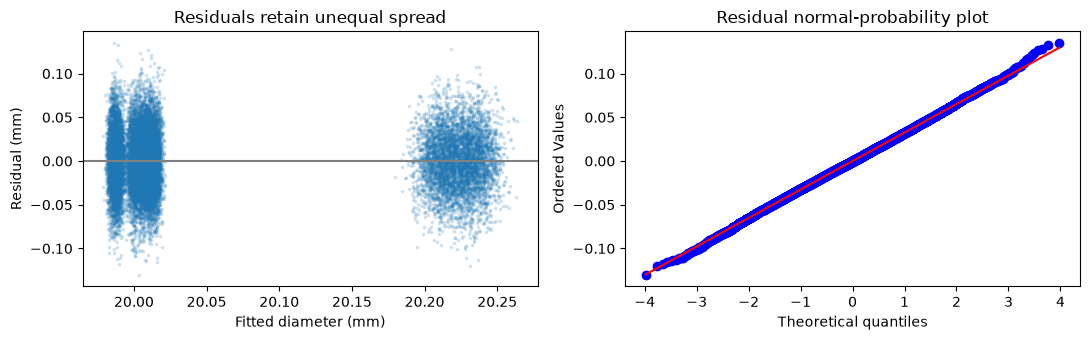

,count,Conditional_residual_SD_mm
Supplier,,
Supplier A,6643,0.029351
Supplier B,6660,0.036904
Supplier C,6697,0.031024


In [4]:
from statsmodels.formula.api import ols
model_data=d.assign(Temperature_centered=d.Temperature_C-22)
model=ols('Diameter_mm ~ C(Machine)*Temperature_centered + C(Shift) + C(Supplier)',data=model_data).fit(cov_type='HC3')
ci=model.conf_int()
display(pd.DataFrame({'Coefficient_mm':model.params,'Lower_95':ci[0],'Upper_95':ci[1]}).round(6))
print(f'Descriptive fit R-squared: {model.rsquared:.4f}')
fig,axes=plt.subplots(1,2,figsize=(11,3.5))
axes[0].scatter(model.fittedvalues,model.resid,s=3,alpha=.15)
axes[0].axhline(0,color='gray');axes[0].set(xlabel='Fitted diameter (mm)',ylabel='Residual (mm)',title='Residuals retain unequal spread')
from scipy import stats
stats.probplot(model.resid,plot=axes[1]);axes[1].set_title('Residual normal-probability plot')
plt.tight_layout();plt.show()
display(model_data.assign(Residual=model.resid).groupby('Supplier').Residual.agg(['count','std']).rename(columns={'std':'Conditional_residual_SD_mm'}))

Supplier spread is examined in residuals after accounting for the large machine-center differences, rather than treating pooled machine mixtures as a clean supplier comparison. This remains a descriptive check of the generator.

No pooled Ppk, normal-tail defect prediction or operational SPC claim is used. Day-level dates were randomly assigned, and part IDs do not recover real within-day sequence. A deployment-ready control chart would require a real sampling and ordering design plus a stable baseline.

## 4. Ideal centering: dimensional and total outcomes differ

In [5]:
centered=generate_production_data(process_centered=True)
comparison=pd.DataFrame({'Baseline':summary(d),'Ideal centering':summary(centered)}).T
display(comparison)
print('Net failures avoided:',summary(d)['failures']-summary(centered)['failures'])
display(pd.crosstab(d.Defect_Type,centered.Defect_Type))

,parts,failures,passes,pass_rate,ppm,diameter_failures,length_failures
Baseline,20000.0,1067.0,18933.0,0.94665,53350.0,80.0,2.0
Ideal centering,20000.0,992.0,19008.0,0.95040,49600.0,0.0,2.0


Net failures avoided: 75


Defect_Type,Burr,Length,None,Surface finish,Taper,Tool mark
Defect_Type,,,,,,
Burr,211,0,0,0,0,0
Length,0,2,0,0,0,0
None,0,0,18933,0,0,0
Oversize,1,0,75,0,3,1
Surface finish,0,0,0,407,0,0
Taper,0,0,0,0,206,0
Tool mark,0,0,0,0,0,161


The +0.220 mm M3 offset becomes zero; thermal sensitivity and all random draws remain paired. Diameter failures fall from 80 to zero in seed 42, while total failures fall by 75. Five formerly oversize parts receive other primary labels under the sequential classification model. Two length failures remain.

This is an idealized parameter change, not a controlled production experiment. There is no modeled offset-adjustment cost, downtime, wear, drift or achieved savings.

## 5. Sensitivity to remaining offset and random seed

Thirty paired seeds (0–29), each with 20,000 parts, compare the original +0.220 mm offset with residual offsets of 0, 0.05, 0.10, 0.15 and 0.22 mm. These are analyst-selected scenarios, not empirically calibrated adjustment-error probabilities. The range is simulation variability, not a confidence interval for real-world improvement.

In [6]:
s=pd.read_csv(ROOT/'results/sensitivity.csv')
display(s.groupby('residual_offset_mm').avoided_failures.agg(['count','mean','min','max']).round(2))
ideal=s.loc[s.residual_offset_mm.eq(0),'avoided_failures']
print(f'Ideal centering across 30 seeds: mean {ideal.mean():.1f}, range {ideal.min()}–{ideal.max()} net failures avoided per 20,000 parts.')

,count,mean,min,max
residual_offset_mm,,,,
0.00,30,63.87,45,80
0.05,30,63.87,45,80
0.10,30,63.87,45,80
0.15,30,63.70,45,80
0.22,30,0.00,0,0


Ideal centering across 30 seeds: mean 63.9, range 45–80 net failures avoided per 20,000 parts.


## 6. Decision and next evidence

Within this model, centering addresses the diameter offset but leaves most inspection losses. A next engineering investigation would separately assess surface-acceptance criteria, actual adjustment reliability and cost, then run independent confirmation trials. The synthetic category called surface finish is not a measured Ra result.

The proposed process/CTQ mapping, control plan and qualitative risk review describe evidence needed before deployment. They do not claim factory implementation or invented priority ratings. The drawing remains an optional specification exercise; its hole, geometric controls and roughness are not measured in this dataset.

### Interpretation references

- [NIST: process stability](https://www.itl.nist.gov/div898/handbook/ppc/section4/ppc45.htm)
- [Minitab: Gage R&R interpretation](https://blog.minitab.com/en/blog/quality-data-analysis-and-statistics/how-to-interpret-gage-output-part-2)

All numerical production and measurement results above are generated simulation outputs. See `reports/methods.md` for definitions, assumptions and reproducibility.